In [19]:
import random
import itertools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

In [33]:
baseline = 'FluSight-baseline'
gmean = False
log = False
objective = 'WIS'

In [34]:
# load in accuracy data
df = pd.read_csv('accuracy.csv', dtype={'location': str})
df['reference_date'] = pd.to_datetime(df['reference_date'])

# limit range
df = df[df['reference_date'] <= datetime(2026,5,23)]

# omit US
df = df[df['location'] != 'US']

# compute the fraction of NaNs
nan_fraction_per_model = (
    df
    .assign(is_nan=df[objective].isna())
    .groupby("model")["is_nan"]
    .mean()
)

# exclude if fraction of NaNs is higher than 5%
df = df[df['model'].isin(nan_fraction_per_model[nan_fraction_per_model <= min(nan_fraction_per_model)].index.values)]

print(f"Number of included models with 100% forecast coverage: {len(df['model'].unique())}")


Number of included models with 100% forecast coverage: 19


### Compute ranking based on all data

In [35]:
# log score?
if log:
    df[objective] = np.log(df[objective])

# compute global WIS at once
ref_dates = np.sort(df['reference_date'].unique())
results = []

for i, ref_date in enumerate(ref_dates):
    # consider all reference dates up to current
    current_window = ref_dates[:i+1]
    # subset dataframe
    df_window = df[df['reference_date'].isin(current_window)]
    # sum all WIS scores per model
    if gmean == True:
        WIS_sum = df_window.groupby(by='model')[objective].apply(lambda x: np.exp( (1 / len(x)) * np.sum(np.log(x))) ).to_frame()
    else:
        WIS_sum = df_window.groupby(by='model')[objective].sum().to_frame()
    # normalise with the baseline
    WIS_sum[f'rel_{objective}'] = WIS_sum / WIS_sum.loc[baseline]
    WIS_sum = WIS_sum.reset_index()
    # attach current "as-of" reference date
    WIS_sum['as_of'] = ref_date
    results.append(WIS_sum)
# combine all weeks
ranking_df = pd.concat(results, ignore_index=True)
# compute final ranking
complete_ranking = ranking_df[ranking_df['as_of'] == max(ranking_df['as_of'])]
complete_ranking = complete_ranking.sort_values(f'rel_{objective}')
complete_ranking['rank'] = complete_ranking[f'rel_{objective}'].rank(ascending=True, method='dense')
complete_ranking = complete_ranking.sort_values(by='model')

### Leave each week out for my model and compute the difference in rank

In [36]:
delta_ranking = []
for i, ref_date in enumerate(ref_dates):
    
    # omit ref date from df for my model
    df_mymodel = df[((df['reference_date'] != ref_date) & (df['model'] == 'Cornell_JHU-hierarchSIR'))]
    df_omit_mymodel = df[df['model'] != 'Cornell_JHU-hierarchSIR']
    df_omit = pd.concat([df_mymodel, df_omit_mymodel])

    # sum all WIS scores per model
    if gmean == True:
        WIS_sum = df_omit.groupby(by='model')[objective].apply(lambda x: np.exp(np.sum(np.log(x))/len(x)) ).to_frame()
    else:
        WIS_sum = df_omit.groupby(by='model')[objective].mean().to_frame()
        
    # normalize with the baseline
    WIS_sum[f'rel_{objective}'] = WIS_sum / WIS_sum.loc[baseline]
    WIS_sum = WIS_sum.reset_index()
    
    # compute ranking
    ranking = WIS_sum.sort_values(f'rel_{objective}')
    ranking['new_rank'] = ranking[f'rel_{objective}'].rank(ascending=True, method='dense')
    
    # sort by model
    ranking = ranking.sort_values(by='model')
    ranking['left_out_refdate'] = ref_date
    ranking['delta_ranking'] = ranking['new_rank'].values - complete_ranking['rank'].values
    ranking['old_rank'] = int(complete_ranking.loc[complete_ranking['model'] == 'Cornell_JHU-hierarchSIR', 'rank'].values[0])
    delta_ranking.append(ranking)

delta_ranking = pd.concat(delta_ranking)

In [37]:
delta_ranking = delta_ranking[delta_ranking['model'] == 'Cornell_JHU-hierarchSIR']

fig,ax=plt.subplots(figsize=(8.3, 11.7/4))
ax.plot(delta_ranking['left_out_refdate'], delta_ranking['old_rank'], color='black', label='End-of-season ranking with 100% forecasts submitted')
ax.plot(delta_ranking['left_out_refdate'], delta_ranking['new_rank'], marker='o', color='red', label='End-of-season ranking if one forecast week is ommitted')
ax.set_xlabel("Ommitted week")
ax.set_ylabel("Ranking")
#ax.set_title(f"rel_{objective} (gmean: {gmean})")
ax.legend()
plt.tight_layout()
plt.savefig('ranking_amean_rel_WIS.svg')
plt.close()

### Leave `m` weeks out at random and recompute ranking

In [8]:
delta_ranking_collect = []

for m in range(1,10):

    all_possibilities = list(itertools.combinations(ref_dates, m))

    print(f"Fraction ommitted: {m/28:.2f}, number of combinations {len(all_possibilities)}")

    delta_ranking = []
    
    for n in range(1000):

        if n > len(all_possibilities):
            break
       
        possibilities = random.choice(all_possibilities) 

        # omit ref dates from df for my model
        df_mymodel = df[((df['reference_date'].isin(possibilities)) & (df['model'] == 'Cornell_JHU-hierarchSIR'))]
        df_omit_mymodel = df[df['model'] != 'Cornell_JHU-hierarchSIR']
        df_omit = pd.concat([df_mymodel, df_omit_mymodel])
    
        # sum all WIS scores per model
        if gmean == True:
            WIS_sum = df_omit.groupby(by='model')[objective].apply(lambda x: np.exp(np.sum(np.log(x))/len(x)) ).to_frame()
        else:
            WIS_sum = df_omit.groupby(by='model')[objective].mean().to_frame()
            
        # normalize with the baseline
        WIS_sum[f'rel_{objective}'] = WIS_sum / WIS_sum.loc[baseline]
        WIS_sum = WIS_sum.reset_index()
        
        # compute ranking
        ranking = WIS_sum.sort_values(f'rel_{objective}')
        ranking['new_rank'] = ranking[f'rel_{objective}'].rank(ascending=True, method='dense')
        
        # sort by model
        ranking = ranking.sort_values(by='model')
        ranking['left_out_refdate'] = ref_date
        ranking['delta_ranking'] = ranking['new_rank'].values - complete_ranking['rank'].values
        ranking['old_rank'] = int(complete_ranking.loc[complete_ranking['model'] == 'Cornell_JHU-hierarchSIR', 'rank'].values[0])
        ranking['repeat_id'] = n
        delta_ranking.append(ranking)

    delta_ranking = pd.concat(delta_ranking)
    delta_ranking = delta_ranking.groupby(by='model')[['new_rank', 'old_rank', 'delta_ranking']].mean().reset_index()
    delta_ranking['fraction_ommitted'] = m/28
    delta_ranking_collect.append(delta_ranking)
    
delta_ranking = pd.concat(delta_ranking_collect)

Fraction ommitted: 0.04, number of combinations 27
Fraction ommitted: 0.07, number of combinations 351
Fraction ommitted: 0.11, number of combinations 2925
Fraction ommitted: 0.14, number of combinations 17550
Fraction ommitted: 0.18, number of combinations 80730
Fraction ommitted: 0.21, number of combinations 296010
Fraction ommitted: 0.25, number of combinations 888030
Fraction ommitted: 0.29, number of combinations 2220075
Fraction ommitted: 0.32, number of combinations 4686825


/var/folders/ny/j5ym9thj7l34rykpfr__k_540000gr/T/ipykernel_23096/1607068083.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


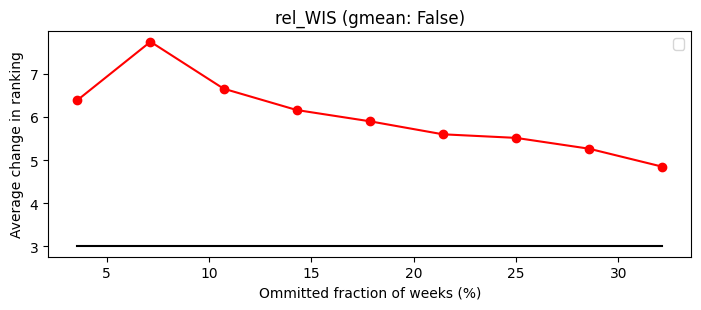

In [9]:
delta_ranking = delta_ranking[delta_ranking['model'] == 'Cornell_JHU-hierarchSIR']

fig,ax=plt.subplots(figsize=(8.3, 11.7/4))
ax.plot(delta_ranking['fraction_ommitted']*100, delta_ranking['old_rank'], color='black')
ax.plot(delta_ranking['fraction_ommitted']*100, delta_ranking['new_rank'], marker='o', color='red')
#ax.plot(delta_ranking['fraction_ommitted']*100, delta_ranking['delta_ranking'], marker='o', color='red')
ax.set_xlabel("Ommitted fraction of weeks (%)")
ax.set_ylabel("Average change in ranking")
ax.set_title(f"rel_{objective} (gmean: {gmean})")
ax.legend()
plt.show()
plt.close()